In [2]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])
  ))

Saving air_traffic_data.csv.zip to air_traffic_data.csv.zip
User uploaded file "air_traffic_data.csv.zip" with length 176707 bytes


In [3]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Unzip the file
with zipfile.ZipFile('air_traffic_data.csv.zip', 'r') as zip_ref:
  zip_ref.extractall()
#Machine Learning
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, silhouette_score
import warnings
warnings.filterwarnings('ignore')


In [4]:
from IPython.core.interactiveshell import default_banner
#Data preprocessing
#Load the data with Pandas
df = pd.read_csv('air_traffic_data.csv')
df

,Activity Period,Operating Airline,Operating Airline IATA Code,Published Airline,Published Airline IATA Code,GEO Summary,GEO Region,Activity Type Code,Price Category Code,Terminal,Boarding Area,Passenger Count,Adjusted Activity Type Code,Adjusted Passenger Count,Year,Month
0,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Deplaned,Low Fare,Terminal 1,B,27271,Deplaned,27271,2005,July
1,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Enplaned,Low Fare,Terminal 1,B,29131,Enplaned,29131,2005,July
2,200507,ATA Airlines,TZ,ATA Airlines,TZ,Domestic,US,Thru / Transit,Low Fare,Terminal 1,B,5415,Thru / Transit * 2,10830,2005,July
3,200507,Air Canada,AC,Air Canada,AC,International,Canada,Deplaned,Other,Terminal 1,B,35156,Deplaned,35156,2005,July
4,200507,Air Canada,AC,Air Canada,AC,International,Canada,Enplaned,Other,Terminal 1,B,34090,Enplaned,34090,2005,July
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15002,201603,Virgin America,VX,Virgin America,VX,Domestic,US,Enplaned,Low Fare,Terminal 2,D,194636,Enplaned,194636,2016,March
15003,201603,Virgin America,VX,Virgin America,VX,International,Mexico,Deplaned,Low Fare,International,A,4189,Deplaned,4189,2016,March
15004,201603,Virgin America,VX,Virgin America,VX,International,Mexico,Enplaned,Low Fare,Terminal 2,D,4693,Enplaned,4693,2016,March
15005,201603,Virgin Atlantic,VS,Virgin Atlantic,VS,International,Europe,Deplaned,Other,International,A,12313,Deplaned,12313,2016,March


In [5]:
#Missing values
df.isnull().sum()

,0
Activity Period,0
Operating Airline,0
Operating Airline IATA Code,54
Published Airline,0
Published Airline IATA Code,54
GEO Summary,0
GEO Region,0
Activity Type Code,0
Price Category Code,0
Terminal,0


In [6]:
df.dtypes

,0
Activity Period,int64
Operating Airline,object
Operating Airline IATA Code,object
Published Airline,object
Published Airline IATA Code,object
GEO Summary,object
GEO Region,object
Activity Type Code,object
Price Category Code,object
Terminal,object


In [7]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
15002,False
15003,False
15004,False
15005,False


In [8]:
#Rename for clarity (adjusted based on actual names)
df.columns = df.columns.str.strip()

In [9]:
#Check unique values in key categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
  print(f"\n{col} unique values: {df[col].nunique()}")
  print(df[col].value_counts().head())



Operating Airline unique values: 77
Operating Airline
United Airlines - Pre 07/01/2013    2154
SkyWest Airlines                     963
United Airlines                      892
Alaska Airlines                      751
Delta Air Lines                      386
Name: count, dtype: int64

Operating Airline IATA Code unique values: 73
Operating Airline IATA Code
UA    3046
OO     963
AS     751
DL     386
AC     366
Name: count, dtype: int64

Published Airline unique values: 68
Published Airline
United Airlines - Pre 07/01/2013    2645
United Airlines                     1107
Alaska Airlines                      969
Delta Air Lines                      803
American Airlines                    416
Name: count, dtype: int64

Published Airline IATA Code unique values: 64
Published Airline IATA Code
UA     3752
AS      969
DL      803
AA      416
US      407
Name: count, dtype: int64

GEO Summary unique values: 2
GEO Summary
International    9210
Domestic         5797
Name: count, dtype: int64

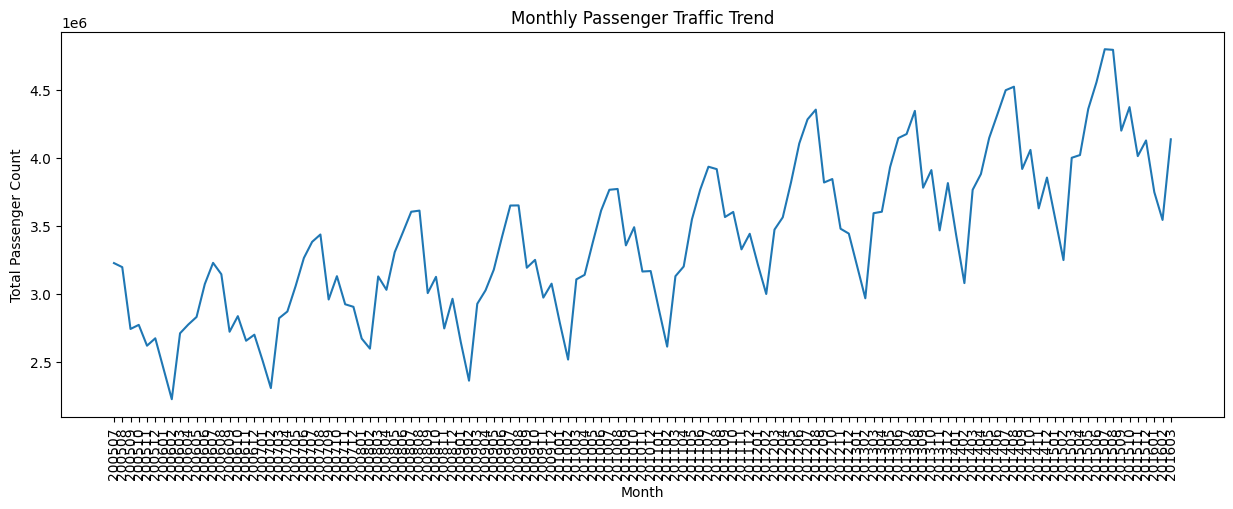

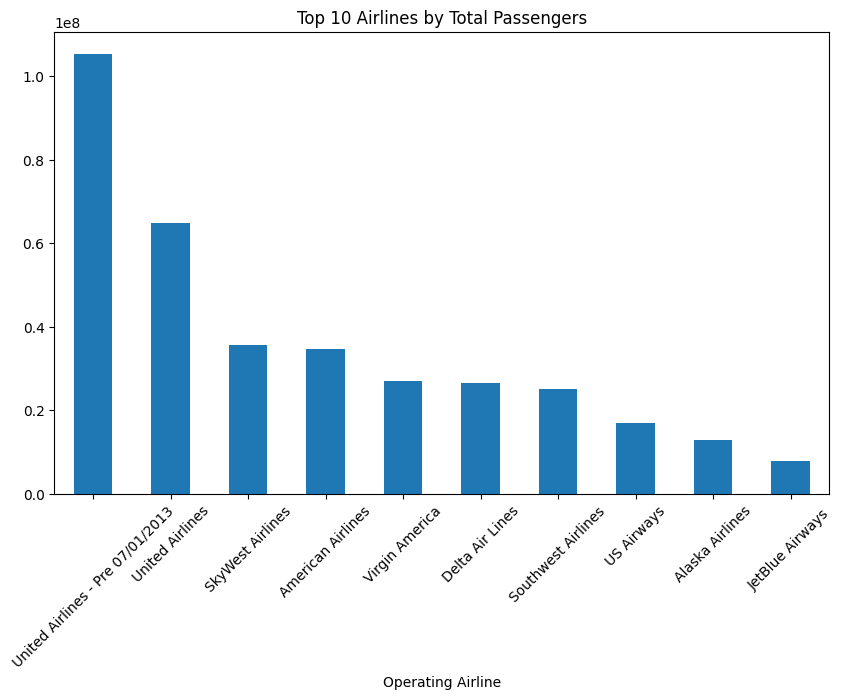

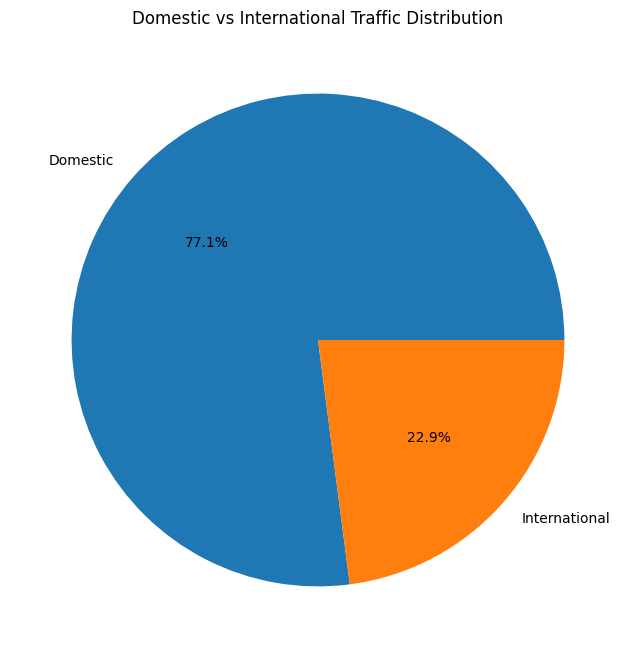

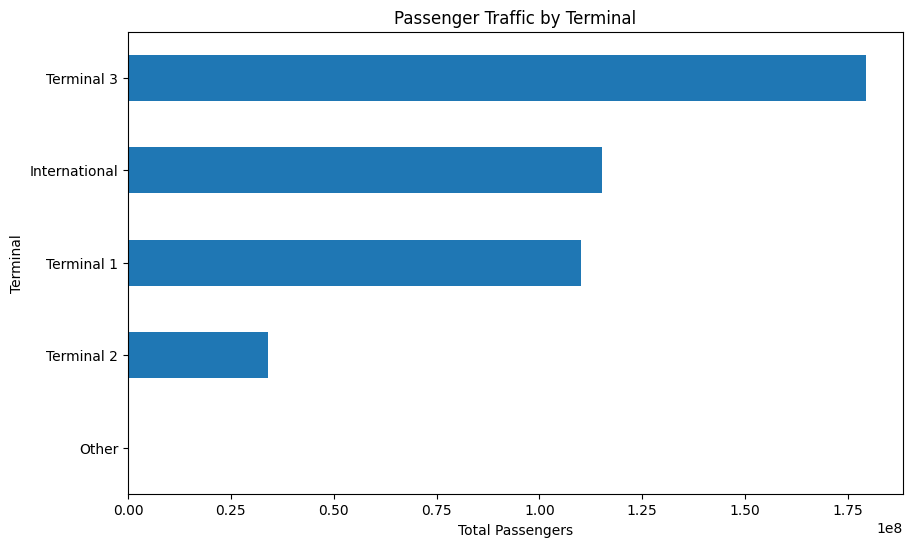

In [14]:
#Exploratory Data Analysis
# 1. Time series trends
if 'Activity Period' in df.columns:
    df['Activity Period'] = df['Activity Period'].astype(str)
    monthly_traffic = df.groupby('Activity Period')['Passenger Count'].sum().reset_index()

    plt.figure(figsize=(15,5))
    plt.plot(monthly_traffic['Activity Period'], monthly_traffic['Passenger Count'])
    plt.title('Monthly Passenger Traffic Trend')
    plt.xticks(rotation=90)
    plt.xlabel('Month')
    plt.ylabel('Total Passenger Count')
    plt.show()

# 2. Top airlines by passenger volume
airline_traffic = df.groupby('Operating Airline')['Passenger Count'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
airline_traffic.plot(kind='bar')
plt.title('Top 10 Airlines by Total Passengers')
plt.xticks(rotation=45)
plt.show()

# 3. Domestic vs International split
geo_traffic = df.groupby('GEO Summary')['Passenger Count'].sum()
plt.figure(figsize=(8,8))
plt.pie(geo_traffic, labels=geo_traffic.index, autopct='%1.1f%%')
plt.title('Domestic vs International Traffic Distribution')
plt.show()

# 4. Terminal analysis
terminal_traffic = df.groupby('Terminal')['Passenger Count'].sum()
plt.figure(figsize=(10,6))
terminal_traffic.sort_values().plot(kind='barh')
plt.title('Passenger Traffic by Terminal')
plt.xlabel('Total Passengers')
plt.show()

Classification Report:
               precision    recall  f1-score   support

           0       0.26      0.27      0.27      1415
           1       0.25      0.25      0.25      1403
           2       0.99      0.96      0.98       184

    accuracy                           0.30      3002
   macro avg       0.50      0.49      0.50      3002
weighted avg       0.30      0.30      0.30      3002

Confusion Matrix:
 [[ 380 1035    0]
 [1049  353    1]
 [   6    2  176]]

 Top 10 Features:
                        feature  importance
0              Passenger Count    0.598672
6                month_encoded    0.136933
5                 year_encoded    0.105898
1    Operating Airline_encoded    0.099793
7           GEO Region_encoded    0.026863
3             Terminal_encoded    0.019560
2          GEO Summary_encoded    0.006671
4  Price Category Code_encoded    0.005609


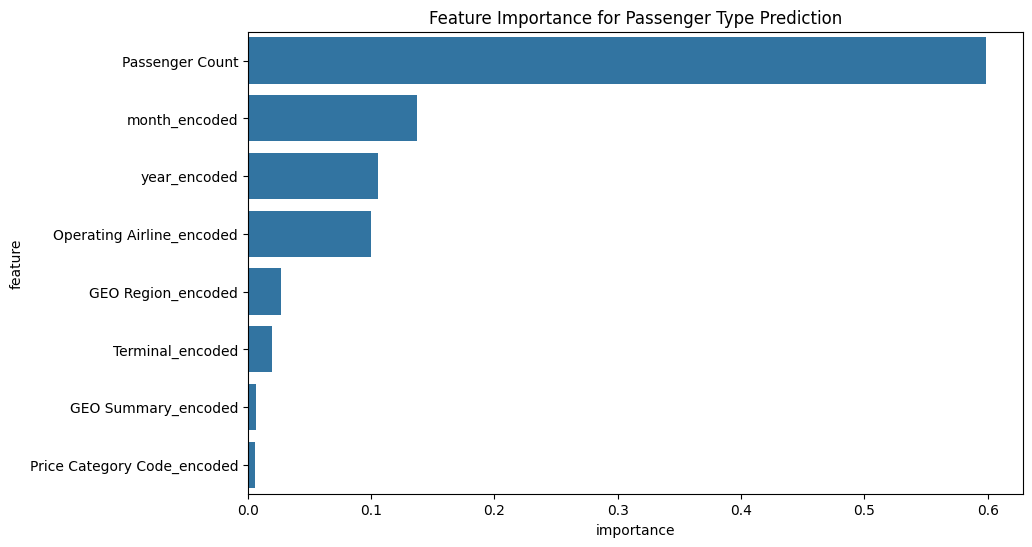

In [20]:
#Classification & Predict Passenger Type (Deplaned/Enplaned/Thru Transit)
#Prepare features
df['target'] = df['Activity Type Code'] #Adjust column name

#Feature engineering
feature_cols = ['Operating Airline', 'GEO Summary', 'GEO Region', 'Terminal', 'Price Category Code']

#Encode categorical variables
label_encoders = {}
for col in feature_cols:
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

#Time-based features
if 'Activity Period' in df.columns:
    df['year'] = df['Activity Period'].astype(str).str[:4]
    df['month'] = df['Activity Period'].astype(str).str[4:6]
    df['year_encoded'] = LabelEncoder().fit_transform(df['year'])
    df['month_encoded'] = LabelEncoder().fit_transform(df['month'])

#Select features for modeling
X_cols = [col for col in df.columns if '_encoded' in col or col in['Passenger Count']]
X = df[X_cols]
y = df['target_encoded'] if 'target_encoded' in df.columns else LabelEncoder().fit_transform(df['target'])

#Train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

#Predict and evaluate
y_pred = rf.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

#Feature importance
feature_importance = pd.DataFrame({'feature': X_cols, 'importance': rf.feature_importances_}).sort_values('importance', ascending=False)
print("\n Top 10 Features:\n", feature_importance.head(10))

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance for Passenger Type Prediction')
plt.show()

In [22]:
#Predict Price Category,Binary Classfication:(Low Fare vs Other)
df['is_low_fare'] = (df['Price Category Code'] == 'Low Fare').astype(int)

#Prepae features (similar to above)
X_binary = df[X_cols]
y_binary = df['is_low_fare']

#Train_test_split
X_train_binary, X_test_binary, y_train_binary, y_test_binary = train_test_split(
    X_binary, y_binary, test_size=0.2, random_state=42
)

#Train model
rf_binary = RandomForestClassifier(n_estimators=100, random_state=42)
#Fit the model
rf_binary.fit(X_train_binary, y_train_binary)
y_pred_binary = rf_binary.predict(X_test_binary)

print("Low Fare Prediction Report:\n", classification_report(y_test_binary, y_pred_binary))
print("Low Fare Confusion Matrix:\n", confusion_matrix(y_test_binary, y_pred_binary))

Low Fare Prediction Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2618
           1       1.00      1.00      1.00       384

    accuracy                           1.00      3002
   macro avg       1.00      1.00      1.00      3002
weighted avg       1.00      1.00      1.00      3002

Low Fare Confusion Matrix:
 [[2618    0]
 [   0  384]]


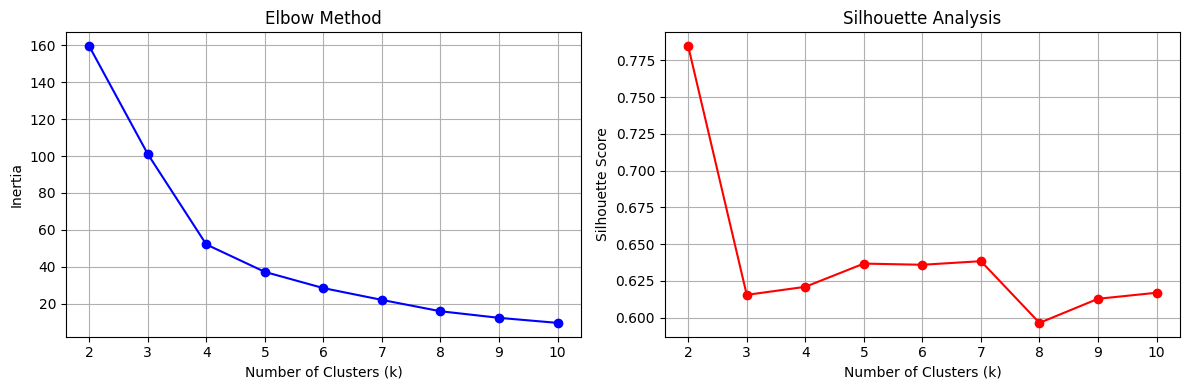

Cluster Characteristics:
         Total_Passengers       Avg_Passengers Frequency  \
                    mean count           mean      mean   
Cluster                                                   
0              290938.66    58        3986.46     46.36   
1            33440102.00     6      101215.63    348.50   
2             3787694.19    37       15844.64    255.08   
3            81152761.00     1      102855.21    789.00   

                                                   Airline  
                                                  <lambda>  
Cluster                                                     
0        [ATA Airlines, Aer Lingus, Air Berlin, Air Can...  
1        [American Airlines, Delta Air Lines, SkyWest A...  
2        [Aeromexico, Air Canada , Air China, Air Franc...  
3                       [United Airlines - Pre 07/01/2013]  


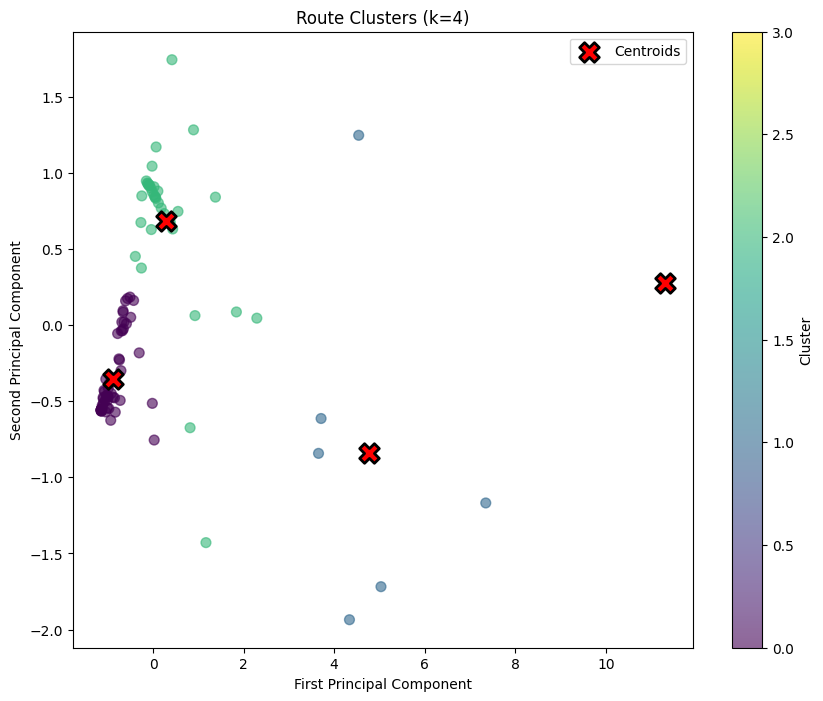


Cluster Distribution:
 Cluster_Label
High Volume Routes         58
Medium Frequency Routes    37
Low Volume Routes           6
Seasonal/Niche Routes       1
Name: count, dtype: int64


In [24]:
#Clustering Analysis
# Aggregate data by airline and route
route_data = df.groupby(['Operating Airline', 'GEO Summary', 'GEO Region']).agg({
    'Passenger Count': ['sum', 'mean', 'count'],
    'Activity Period': lambda x: x.nunique()  # number of months active
}).reset_index()

# Flatten column names
route_data.columns = ['Airline', 'Geo_Summary', 'Geo_Region',
                      'Total_Passengers', 'Avg_Passengers', 'Frequency', 'Active_Months']

# Calculate additional metrics
route_data['avg_per_month'] = route_data['Total_Passengers'] / route_data['Active_Months']
route_data['density'] = route_data['Total_Passengers'] / route_data['Frequency']

# Select features for clustering
cluster_features = ['Total_Passengers', 'Avg_Passengers', 'Frequency', 'avg_per_month']
X_cluster = route_data[cluster_features]

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Find optimal k using elbow method
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot elbow curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
ax1.plot(K_range, inertia, 'bo-')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True)

ax2.plot(K_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.grid(True)

plt.tight_layout()
plt.show()

# Choose optimal k (e.g., 4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
route_data['Cluster'] = kmeans.fit_predict(X_scaled)

# Analyze clusters
cluster_summary = route_data.groupby('Cluster').agg({
    'Total_Passengers': ['mean', 'count'],
    'Avg_Passengers': 'mean',
    'Frequency': 'mean',
    'Airline': lambda x: list(x.unique())[:5]  # Top 5 airlines
}).round(2)

print("Cluster Characteristics:\n", cluster_summary)

# Visualize clusters
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=route_data['Cluster'],
                      cmap='viridis', s=50, alpha=0.6)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title(f'Route Clusters (k={optimal_k})')

# Add labels for cluster centers
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', s=200,
            edgecolors='black', linewidths=2, label='Centroids')
plt.legend()
plt.show()

# Interpret clusters
cluster_labels = {
    0: "High Volume Routes",
    1: "Low Volume Routes",
    2: "Medium Frequency Routes",
    3: "Seasonal/Niche Routes"
}
route_data['Cluster_Label'] = route_data['Cluster'].map(cluster_labels)
print("\nCluster Distribution:\n", route_data['Cluster_Label'].value_counts())

In [29]:
#Advanced Insights & Insights
# 1. Identify fastest growing routes
df['year'] = df['Activity Period'].astype(str).str[:4]
yearly_traffic = df.groupby(['Operating Airline', 'GEO Region', 'year'])['Passenger Count'].sum().reset_index()

# Calculate year-over-year growth
pivot_traffic = yearly_traffic.pivot_table(
    index=['Operating Airline', 'GEO Region'],
    columns='year',
    values='Passenger Count',
    fill_value=0
)

if '2015' in pivot_traffic.columns and '2016' in pivot_traffic.columns:
    pivot_traffic['growth'] = ((pivot_traffic['2016'] - pivot_traffic['2015']) /
                                pivot_traffic['2015'] * 100).replace([np.inf, -np.inf], 0)
    top_growth = pivot_traffic.nlargest(10, 'growth')
    print("Top 10 Fastest Growing Routes:\n", top_growth[['2015', '2016', 'growth']])

# 2. Terminal optimization suggestions
terminal_by_type = df.groupby(['Terminal', 'Activity Type Code'])['Passenger Count'].sum().unstack()
print("\nTerminal Usage by Passenger Type:\n", terminal_by_type)

# 3. Low fare airline analysis
low_fare_airlines = df[df['Price Category Code'] == 'Low Fare'].groupby('Operating Airline')['Passenger Count'].sum().sort_values(ascending=False)
print("\nTop Low Fare Airlines:\n", low_fare_airlines.head(10))

# 4. Export results for reporting
route_data.to_csv('route_clusters.csv', index=False)
feature_importance.to_csv('feature_importance.csv', index=False)

print("\n✅ Analysis Complete! Files saved.")

Top 10 Fastest Growing Routes:
 year                                           2015       2016      growth
Operating Airline    GEO Region                                           
Qantas Airways       Australia / Oceania     4439.0    36484.0  721.896824
Air India Limited    Asia                    5832.0    16844.0  188.820302
Sun Country Airlines Mexico                  4321.0     4111.0   -4.859986
COPA Airlines, Inc.  Central America        24925.0    22928.0   -8.012036
China Southern       Asia                  100178.0    35379.0  -64.683863
Turkish Airlines     Europe                145305.0    50593.0  -65.181515
Korean Air Lines     Asia                  165784.0    52161.0  -68.536771
American Airlines    US                   3238472.0  1006583.0  -68.917965
China Eastern        Asia                  135224.0    37524.0  -72.250488
United Airlines      Mexico                507331.0   139812.0  -72.441660

Terminal Usage by Passenger Type:
 Activity Type Code    Deplaned  